# Fermionic fast Fourier transform

The discrete Fourier transform on fermionic creation operators is defined as:

$$
a^\dagger_k \mapsto \frac{1}{\sqrt{N}} \sum_{n=0}^{N-1} e^{-i 2\pi k n / N} a^\dagger_n
$$

This is an orbital rotation whose matrix is the unitary DFT matrix $F_N$ with entries $(F_N)_{kn} = \omega_N^{kn} / \sqrt{N}$, where $\omega_N = e^{-i 2\pi / N}$. Rather than decomposing $F_N$ directly into Givens rotations, the **fermionic fast Fourier transform (FFFT)** uses the [Cooley-Tukey](https://en.wikipedia.org/wiki/Cooley%E2%80%93Tukey_FFT_algorithm) algorithm to break it into DFTs of prime size.

## Mixed-radix Cooley-Tukey algorithm

The circuit follows the general factorization described in the [Variations](https://en.wikipedia.org/wiki/Cooley%E2%80%93Tukey_FFT_algorithm#Variations) section of the Cooley-Tukey FFT algorithm Wikipedia page. First, $N$ is factored into primes using trial division (this is the simple method, which mght be improved in future). Writing $N = N_1 N_2$, where $N_2$ is the smallest prime factor, and splitting the input index as $n = N_1 n_2 + n_1$ and the output index as $k = N_2 k_1 + k_2$, the DFT becomes

$$
X_{N_2 k_1 + k_2} =
    \sum_{n_1=0}^{N_1-1}
      \left[ e^{-\frac{2\pi i}{N_1N_2} n_1 k_2 } \right]
      \left( \sum_{n_2=0}^{N_2-1} x_{N_1 n_2 + n_1}
              e^{-\frac{2\pi i}{N_2} n_2 k_2 } \right)
      e^{-\frac{2\pi i}{N_1} n_1 k_1 }
$$

where each inner sum is a DFT of size $N_2$, each outer sum is a DFT of size $N_1$.

The circuit follows this formula:

1. Perform $N_1$ DFTs of size $N_2$, one for each $n_1$ (the inner sum). Since $N_2$ is prime, each is implemented directly as an orbital rotation.
2. Multiply by the twiddle factors $e^{-\frac{2\pi i}{N_1N_2} n_1 k_2 }$. Each twiddle factor multiplies a single mode, so it is implemented with a single-qubit phase gate.
3. Perform $N_2$ DFTs of size $N_1$, one for each $k_2$ (the outer sum). These are computed by applying the same procedure recursively.

The recursion ends when the size is prime, in which case the DFT is implemented directly as an orbital rotation.

Under the Jordan-Wigner transformation, a gate implementing an orbital rotation must act on a contiguous block of qubits, because a hopping term between two modes carries a string of $Z$ operators on all the qubits in between. The DFTs in steps 1 and 3 act on strided subsets of modes, so the circuit inserts fermionic mode permutations (themselves orbital rotations by permutation matrices) that bring each subset onto adjacent qubits before the DFTs are applied.

## Quantum circuit implementation

Under the [Jordan-Wigner transformation](https://en.wikipedia.org/wiki/Jordan%E2%80%93Wigner_transformation), `FermionicFFTSpinlessJW` and `FermionicFFTJW` construct quantum circuits for single-spin and spinful systems, respectively.

The following code cell constructs and displays a Qiskit circuit for implementing the fermionic fast Fourier transform on $N = 6$ spatial orbitals, so $N_2 = 2$ and $N_1 = 3$. In the decomposed circuit you can see the mode permutations, the three size-2 DFTs of step 1 and the two size-3 DFTs of step 3 (as orbital rotations), and the twiddle-factor phase gates of step 2.

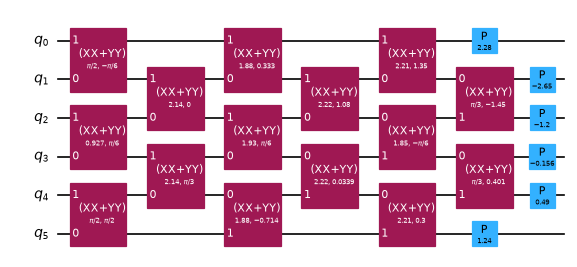

In [1]:
from qiskit.circuit import QuantumCircuit, QuantumRegister

import ffsim
from ffsim.qiskit.gates.fermionic_fft import FermionicFFTJW, FermionicFFTSpinlessJW

norb = 6

# Spinless FFFT circuit (acts on norb qubits)
qubits = QuantumRegister(norb, name="q")
circuit = QuantumCircuit(qubits)
circuit.append(FermionicFFTSpinlessJW(norb), qubits)

# Decompose and draw
circuit.decompose().draw("mpl", scale=0.6)

We can check that the circuit implements the DFT orbital rotation by comparing it against `ffsim.apply_orbital_rotation` with the DFT matrix on a random state.

In [2]:
import numpy as np
import scipy.linalg
from qiskit.quantum_info import Statevector

nocc = 3
nelec = (nocc, 0)
vec = ffsim.random.random_state_vector(ffsim.dim(norb, nelec), seed=1234)

# Apply the FFFT circuit to the state
qiskit_vec = ffsim.qiskit.ffsim_vec_to_qiskit_vec(vec, norb=norb, nelec=nelec)
result = Statevector(qiskit_vec).evolve(circuit)
result = ffsim.qiskit.qiskit_vec_to_ffsim_vec(np.array(result), norb=norb, nelec=nelec)

# Apply the DFT matrix as an orbital rotation
dft_mat = scipy.linalg.dft(norb, scale="sqrtn")
expected = ffsim.apply_orbital_rotation(vec, dft_mat, norb=norb, nelec=nelec)

np.allclose(result, expected)

True

For spinful systems across $2 \times \text{norb}$ qubits, `FermionicFFTJW` applies independent sub-circuits for spin alpha (first `norb` qubits) and spin beta (last `norb` qubits).

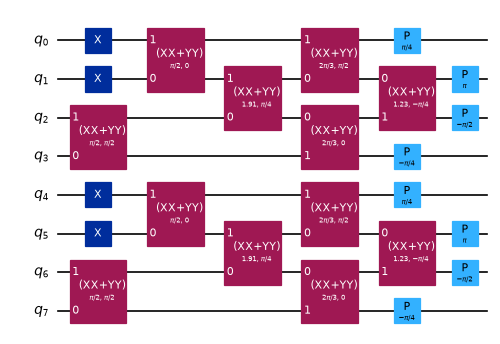

In [3]:
norb = 4
nelec = (2, 2)  # 2 alpha electrons, 2 beta electrons

qubits = QuantumRegister(2 * norb, name="q")
circuit = QuantumCircuit(qubits)
circuit.append(ffsim.qiskit.PrepareHartreeFockJW(norb, nelec), qubits)
circuit.append(FermionicFFTJW(norb), qubits)

# Pre-initialization pass manager optimization
circuit = ffsim.qiskit.PRE_INIT.run(circuit)


circuit.decompose().draw("mpl", scale=0.6)